<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Hybrid_Superconducting_Spin_System_Quantum_Dynamics_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

,material,tc_k,delta0_mev,delta_ind_mev,delta0_over_kbt,xi_nm,transparency,phase_confidence,rank_score,remarks
0,Nb,9.2,1.398,0.417,16.229,40.0,0.85,1.00,0.930,Robust elemental superconductor.
1,δ-TaN,3.6,0.547,0.248,6.350,4.2,0.65,0.80,0.674,Phase sensitive nitride superconductor.
2,strained RuO2,1.0,0.152,0.094,1.764,28.7,0.35,0.45,0.233,Requires preserved epitaxial strain.
3,IrO2,0.0,0.000,0.000,0.000,0.0,0.00,0.05,0.065,Spin orbit oxide with intrinsic gap absent.


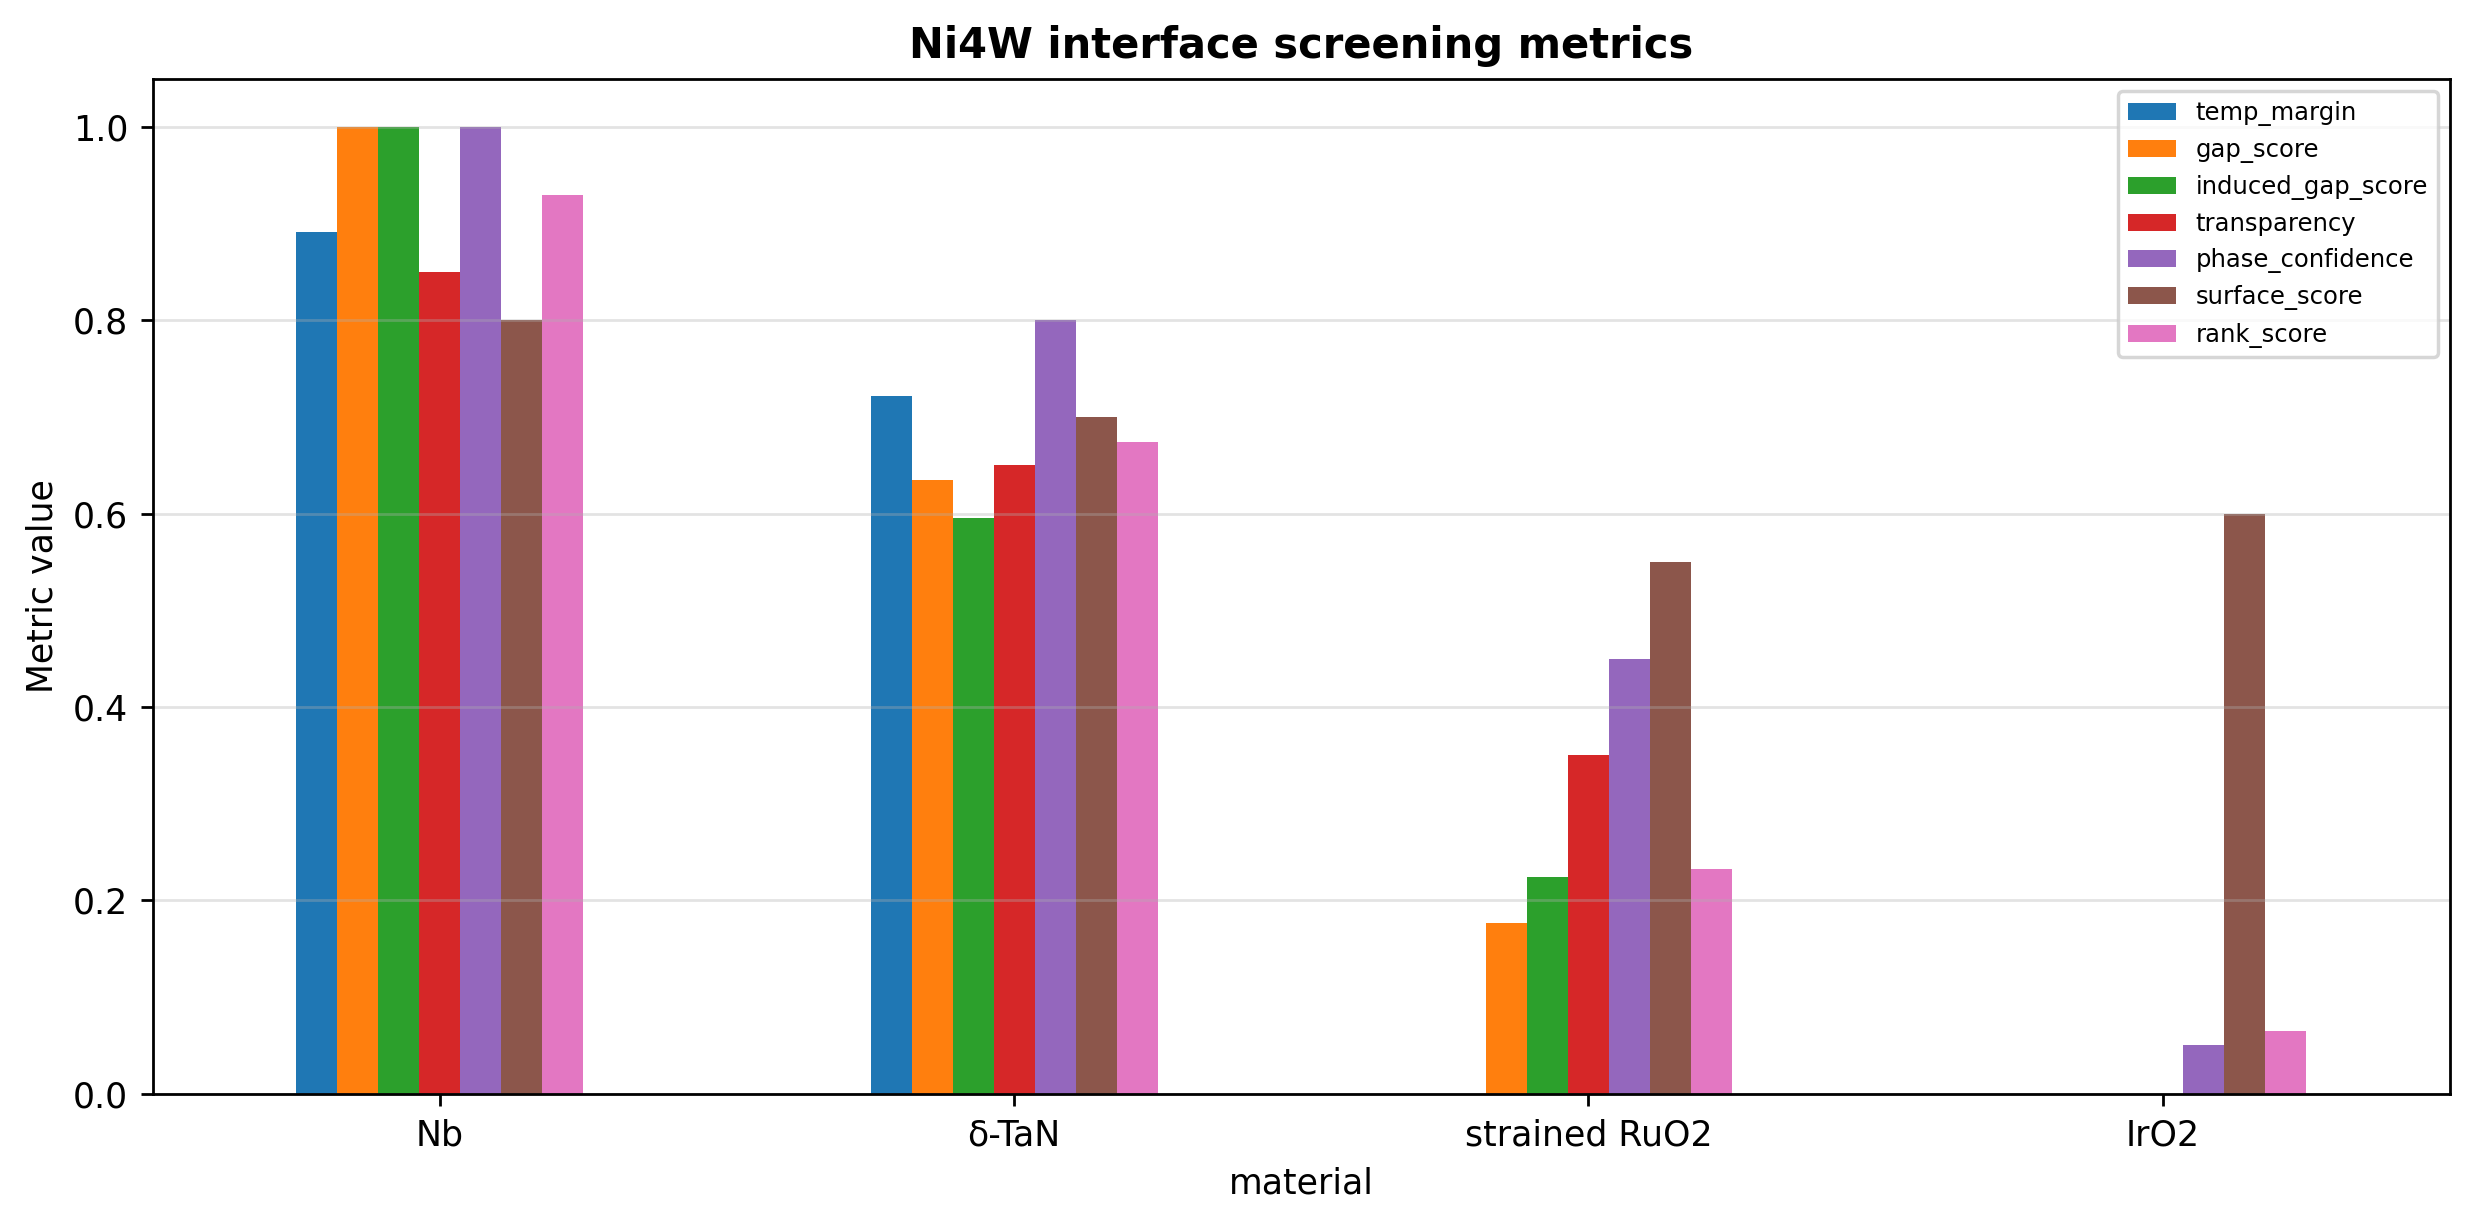

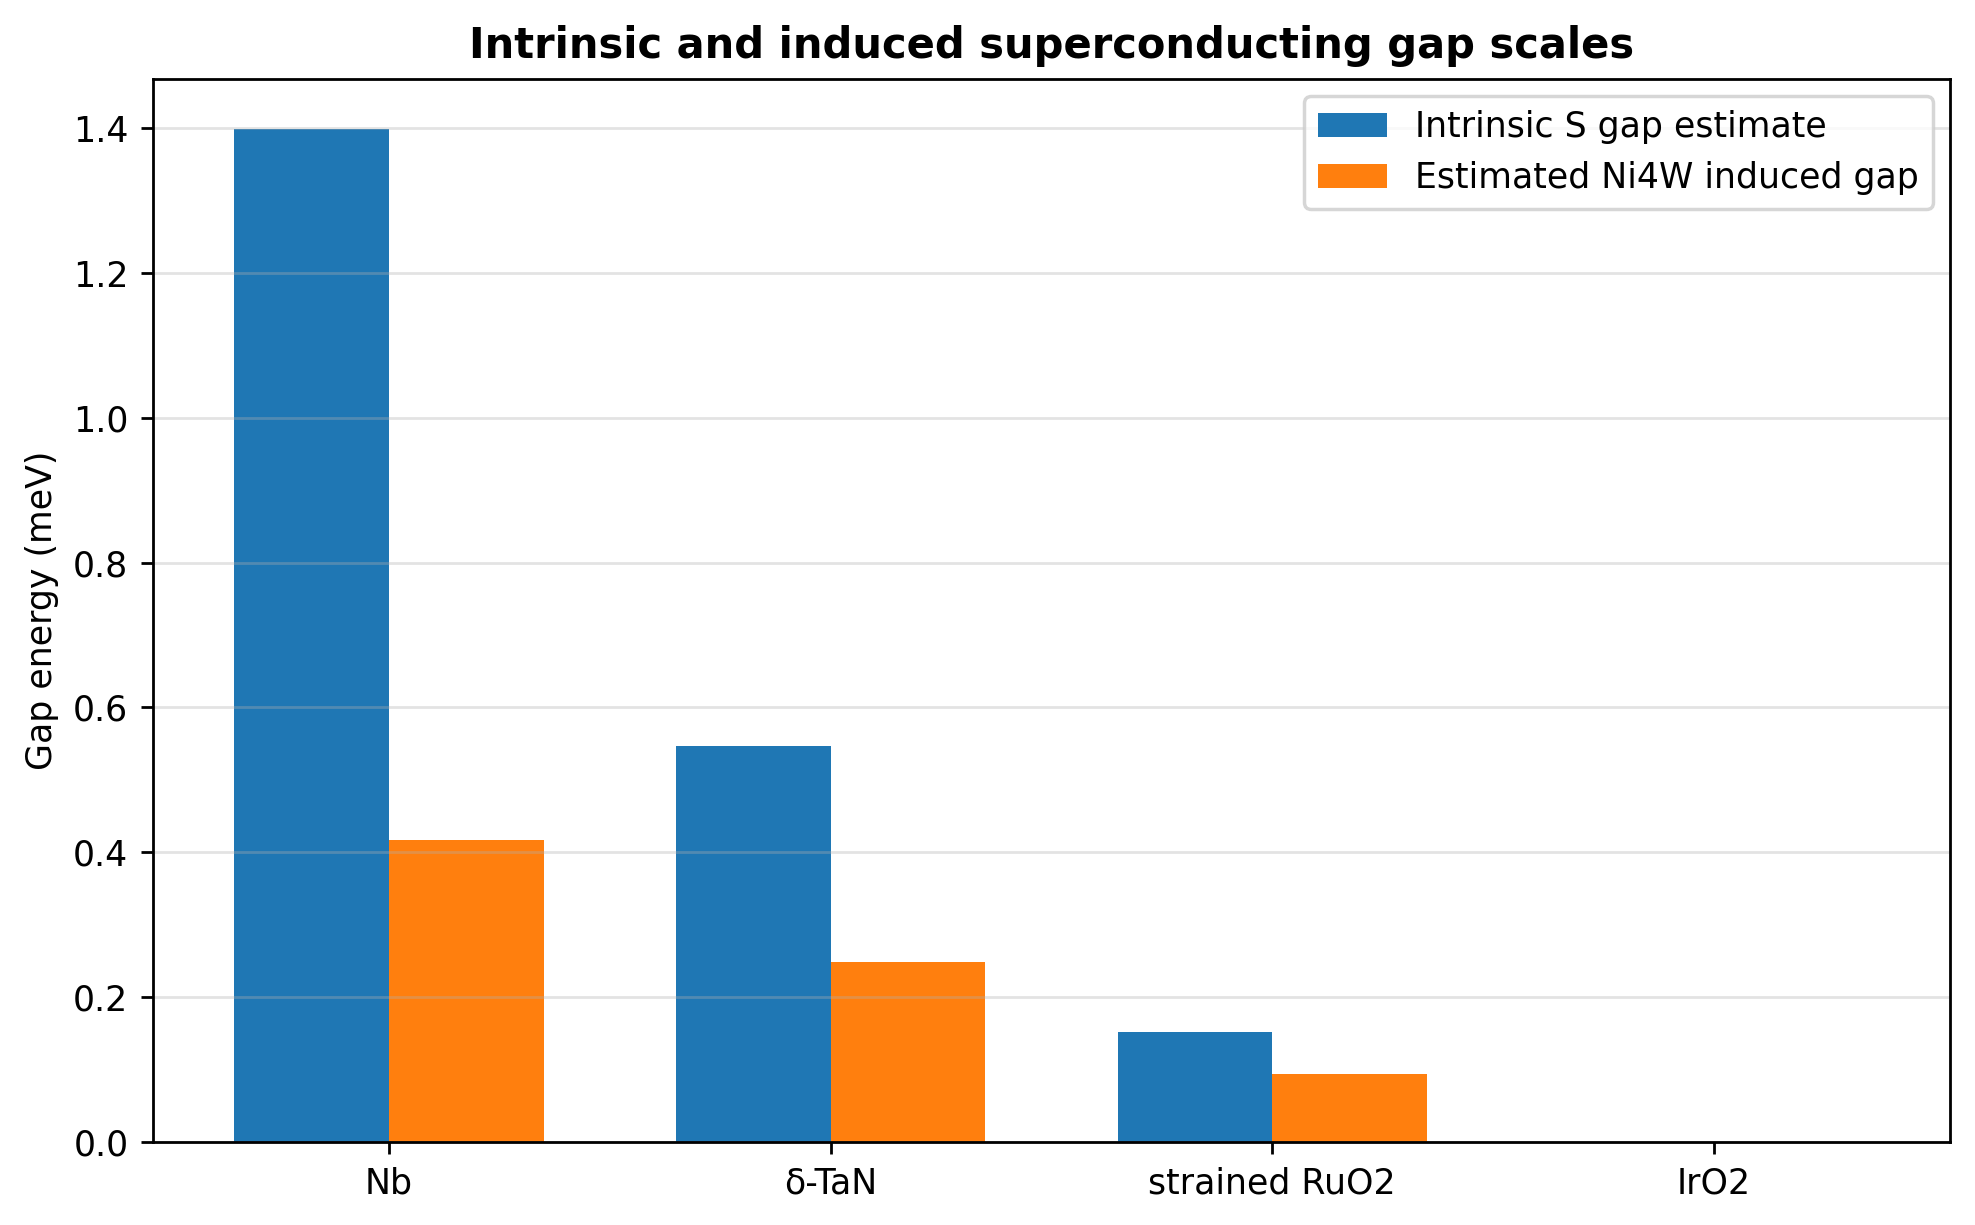

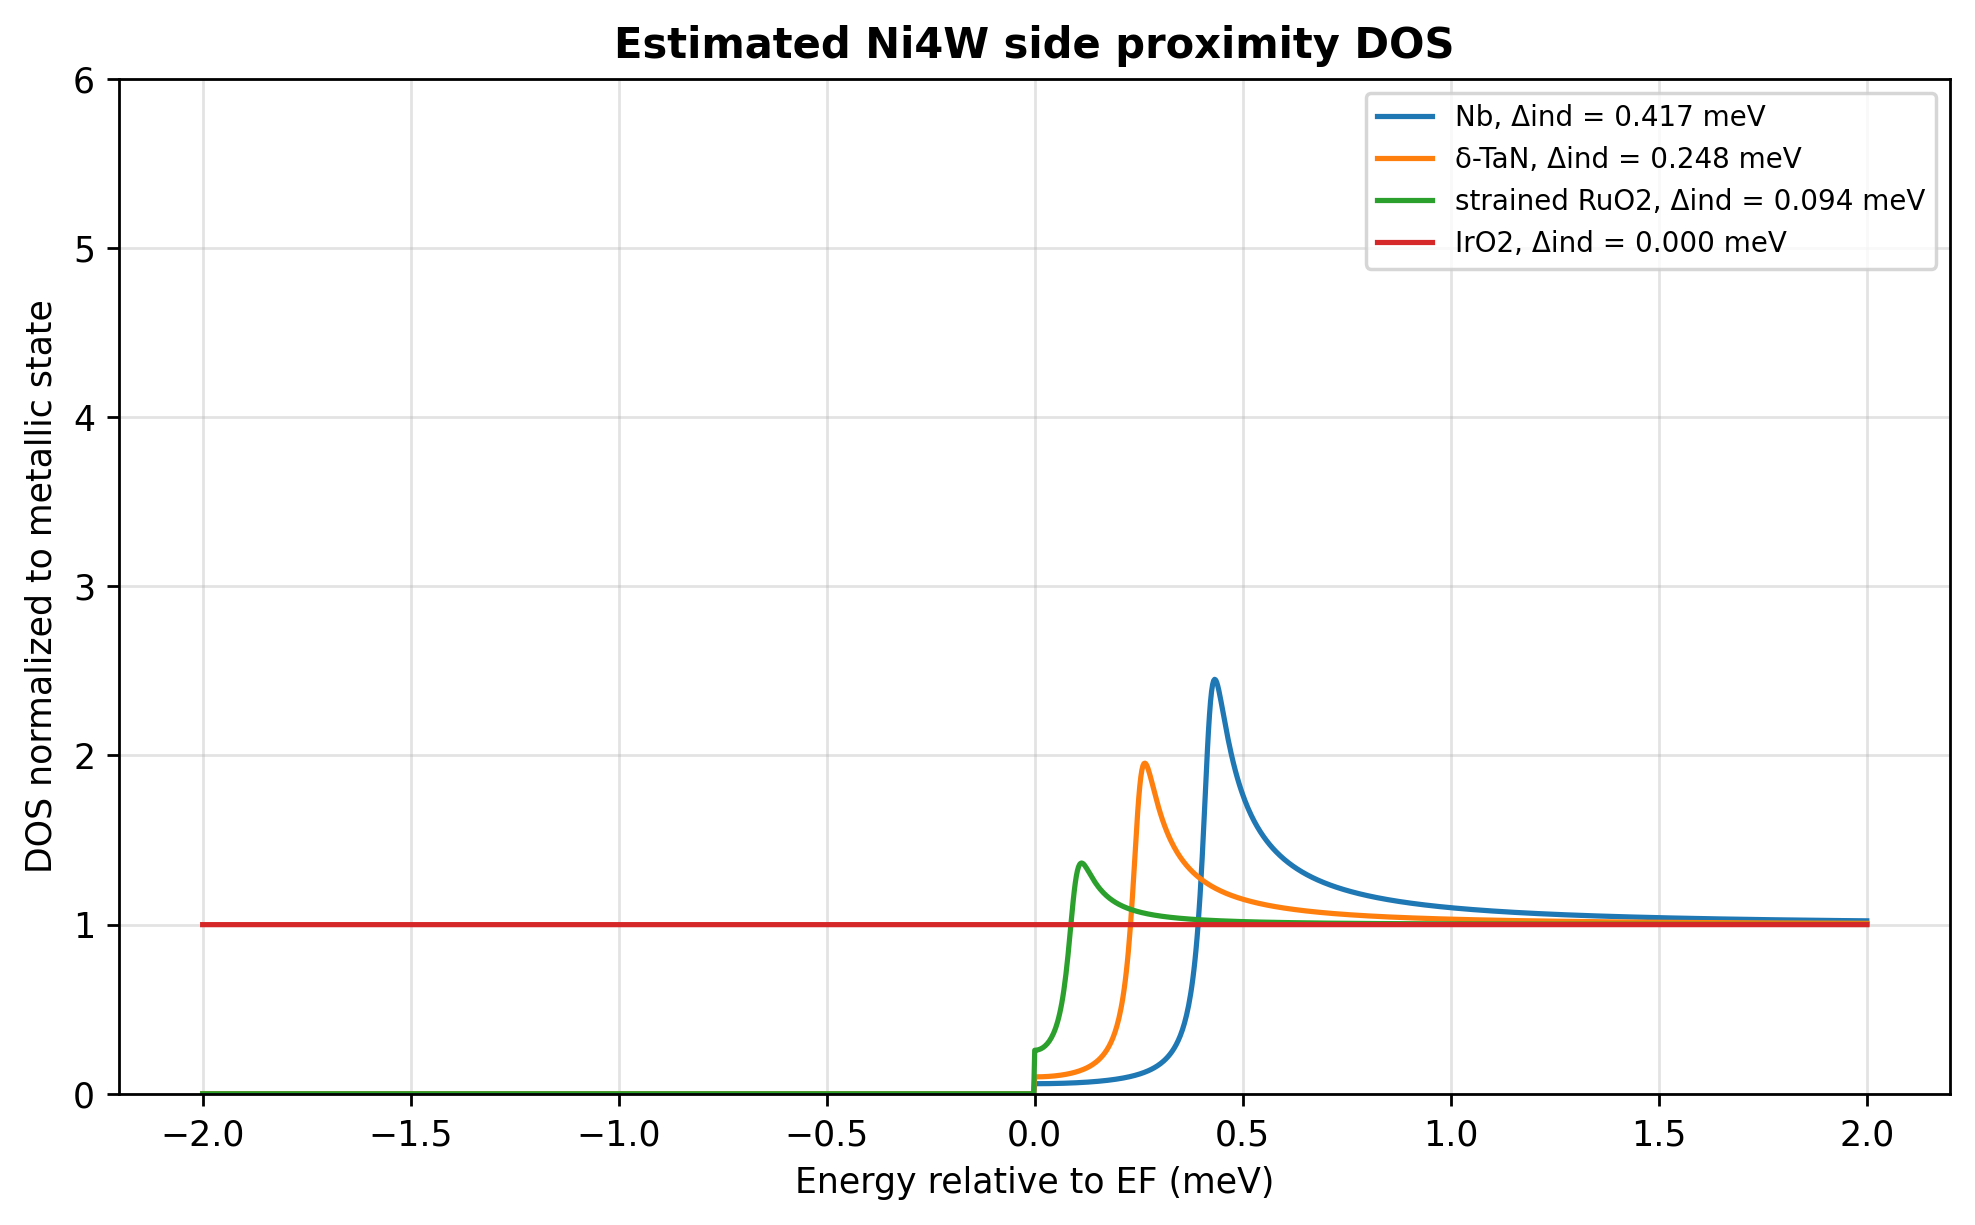

In [8]:
"""Screen Ni4W interfaces using gap scale and induced DOS proxies.

The plots compare intrinsic superconducting energy scale, estimated induced
gap on the Ni4W side, thermal margin, interface transparency, and confidence
in the superconducting state. The DOS plot uses a Dynes form normalized to
the normal state DOS, so IrO2 appears as a flat metallic reference.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib import rcParams


# ---------------------------------------------------------------------------
# Control knobs.
# ---------------------------------------------------------------------------
OPERATING_TEMP_K = 1.0
DYNES_BROADENING_MEV = 0.025
INTERFACE_COUPLING_MEV = 0.70
ENERGY_GRID_MEV = np.linspace(-2.0, 2.0, 1601)
GAP_OVER_KBT_SCALE = 10.0

rcParams["figure.dpi"] = 250
rcParams["savefig.dpi"] = 250


def bcs_gap_mev(tc_k):
    """Return a weak coupling BCS gap estimate in meV."""
    boltzmann_mev_per_k = 0.08617333262
    return 1.764 * boltzmann_mev_per_k * max(tc_k, 0.0)


def thermal_margin(tc_k, operating_temp_k):
    """Return an operating temperature margin bounded from zero to one."""
    if tc_k <= 0.0:
        return 0.0

    margin = (tc_k - operating_temp_k) / tc_k
    return float(np.clip(margin, 0.0, 1.0))


def induced_gap_mev(delta_s_mev, transparency, coupling_mev):
    """Estimate a Ni4W side induced gap from interface coupling."""
    gamma_mev = transparency * coupling_mev
    denominator = delta_s_mev + gamma_mev + 1.0e-12
    return delta_s_mev * gamma_mev / denominator


def dynes_dos(energy_mev, delta_mev, broadening_mev):
    """Return Dynes quasiparticle DOS normalized to normal state DOS."""
    if delta_mev <= 0.0:
        return np.ones_like(energy_mev)

    z_energy = energy_mev + 1j * broadening_mev
    density = np.real(z_energy / np.sqrt(z_energy**2 - delta_mev**2))
    return np.maximum(density, 0.0)


def make_material_frame():
    """Create the material comparison table with derived metrics."""
    data = [
        {
            "material": "Nb",
            "tc_k": 9.2,
            "xi_nm": 40.0,
            "transparency": 0.85,
            "phase_confidence": 1.00,
            "surface_score": 0.80,
            "remarks": "Robust elemental superconductor.",
        },
        {
            "material": "δ-TaN",
            "tc_k": 3.6,
            "xi_nm": 4.2,
            "transparency": 0.65,
            "phase_confidence": 0.80,
            "surface_score": 0.70,
            "remarks": "Phase sensitive nitride superconductor.",
        },
        {
            "material": "strained RuO2",
            "tc_k": 1.0,
            "xi_nm": 28.7,
            "transparency": 0.35,
            "phase_confidence": 0.45,
            "surface_score": 0.55,
            "remarks": "Requires preserved epitaxial strain.",
        },
        {
            "material": "IrO2",
            "tc_k": 0.0,
            "xi_nm": 0.0,
            "transparency": 0.00,
            "phase_confidence": 0.05,
            "surface_score": 0.60,
            "remarks": "Spin orbit oxide with intrinsic gap absent.",
        },
    ]

    frame = pd.DataFrame.from_records(data)
    frame["delta0_mev"] = frame["tc_k"].map(bcs_gap_mev)
    frame["delta_ind_mev"] = [
        induced_gap_mev(row.delta0_mev, row.transparency, INTERFACE_COUPLING_MEV)
        for row in frame.itertuples()
    ]

    kbt_mev = 0.08617333262 * OPERATING_TEMP_K
    frame["delta0_over_kbt"] = frame["delta0_mev"] / kbt_mev
    frame["temp_margin"] = [
        thermal_margin(value, OPERATING_TEMP_K) for value in frame["tc_k"]
    ]

    max_induced_gap = max(frame["delta_ind_mev"].max(), 1.0e-12)
    max_xi_nm = max(frame["xi_nm"].max(), 1.0e-12)

    frame["gap_score"] = np.clip(
        frame["delta0_over_kbt"] / GAP_OVER_KBT_SCALE,
        0.0,
        1.0,
    )
    frame["induced_gap_score"] = frame["delta_ind_mev"] / max_induced_gap
    frame["coherence_score"] = frame["xi_nm"] / max_xi_nm

    frame["rank_score"] = (
        0.25 * frame["temp_margin"]
        + 0.20 * frame["gap_score"]
        + 0.20 * frame["induced_gap_score"]
        + 0.15 * frame["transparency"]
        + 0.10 * frame["phase_confidence"]
        + 0.10 * frame["surface_score"]
    )

    return frame.sort_values("rank_score", ascending=False)


def plot_metric_bars(frame):
    """Plot normalized interface screening metrics."""
    metric_columns = [
        "temp_margin",
        "gap_score",
        "induced_gap_score",
        "transparency",
        "phase_confidence",
        "surface_score",
        "rank_score",
    ]

    ax = frame.set_index("material")[metric_columns].plot(
        kind="bar",
        figsize=(10, 5),
        rot=0,
    )
    ax.set_ylim(0.0, 1.05)
    ax.set_ylabel("Metric value")
    ax.set_title("Ni4W interface screening metrics")
    ax.grid(axis="y", alpha=0.35)
    ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()


def plot_gap_bars(frame):
    """Plot intrinsic and estimated induced gap scales."""
    x_values = np.arange(len(frame))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(
        x_values - width / 2,
        frame["delta0_mev"],
        width,
        label="Intrinsic S gap estimate",
    )
    ax.bar(
        x_values + width / 2,
        frame["delta_ind_mev"],
        width,
        label="Estimated Ni4W induced gap",
    )

    ax.set_xticks(x_values)
    ax.set_xticklabels(frame["material"])
    ax.set_ylabel("Gap energy (meV)")
    ax.set_title("Intrinsic and induced superconducting gap scales")
    ax.grid(axis="y", alpha=0.35)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_induced_dos(frame):
    """Plot Ni4W side Dynes DOS using the induced gap estimate."""
    fig, ax = plt.subplots(figsize=(8, 5))

    for row in frame.itertuples():
        density = dynes_dos(
            ENERGY_GRID_MEV,
            row.delta_ind_mev,
            DYNES_BROADENING_MEV,
        )
        label = f"{row.material}, Δind = {row.delta_ind_mev:.3f} meV"
        ax.plot(ENERGY_GRID_MEV, density, label=label)

    ax.set_ylim(0.0, 6.0)
    ax.set_xlabel("Energy relative to EF (meV)")
    ax.set_ylabel("DOS normalized to metallic state")
    ax.set_title("Estimated Ni4W side proximity DOS")
    ax.grid(alpha=0.35)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


materials = make_material_frame()

display_columns = [
    "material",
    "tc_k",
    "delta0_mev",
    "delta_ind_mev",
    "delta0_over_kbt",
    "xi_nm",
    "transparency",
    "phase_confidence",
    "rank_score",
    "remarks",
]

pd.set_option("display.precision", 3)
display(materials[display_columns])

plot_metric_bars(materials)
plot_gap_bars(materials)
plot_induced_dos(materials)

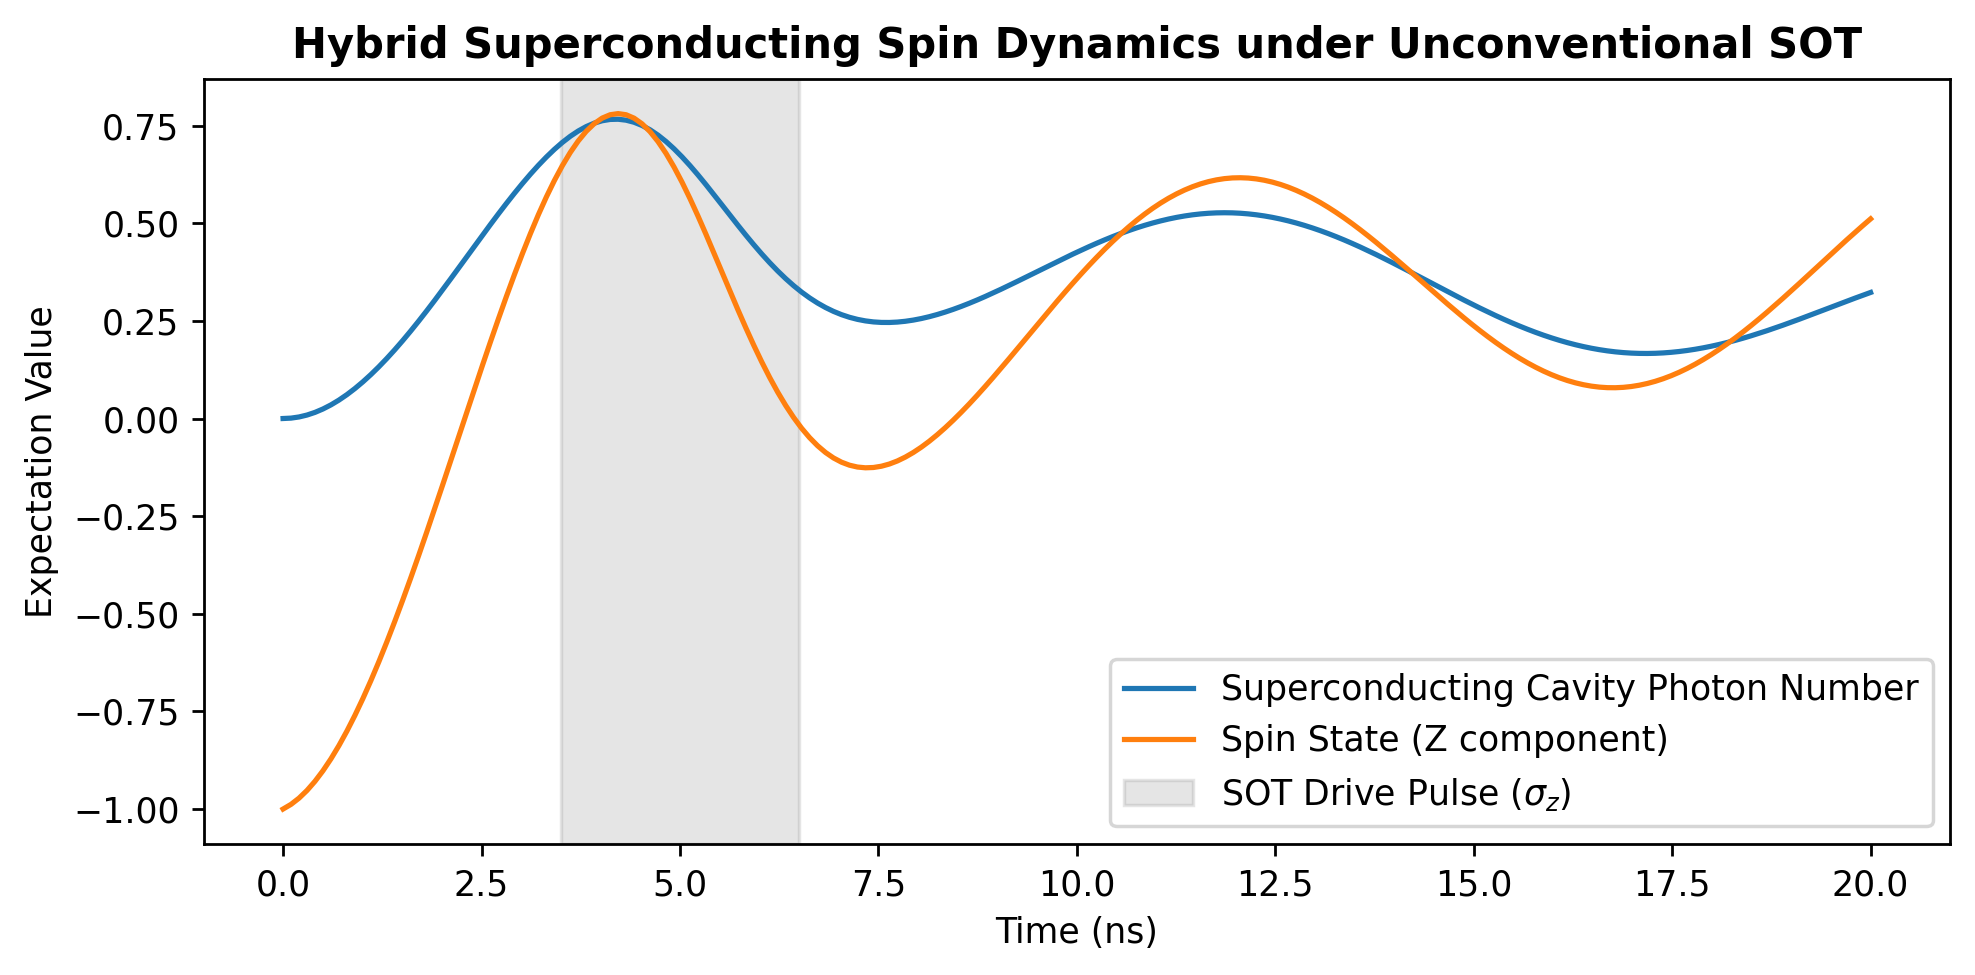

In [5]:
"""
Quantum dynamics of a hybrid superconducting spin system driven by SOT.

This module uses QuTiP to model the interaction between a superconducting
resonator (e.g., Nb cavity) and a coupled spin system, subjected to a
time dependent unconventional SOT pulse generated by a material like Ni4W.
"""

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

# =========================================================
# Control Knobs: System Parameters
# =========================================================
CAVITY_FREQ = 1.0 * 2 * np.pi      # w_c: Superconducting cavity frequency
SPIN_FREQ = 1.0 * 2 * np.pi        # w_s: Spin/Magnon resonant frequency
COUPLING_STR = 0.05 * 2 * np.pi    # g: Cavity spin coupling strength
CAVITY_DECAY = 0.005               # kappa: Photon loss rate
SPIN_DECAY = 0.05                  # gamma: Spin relaxation (Gilbert damping)

# SOT Drive Parameters
SOT_DRIVE_AMP = 0.5                # Amplitude of the out of plane torque
PULSE_CENTER = 5.0                 # t_0: Time center of the SOT pulse
PULSE_WIDTH = 1.5                  # sigma: Gaussian width of the pulse

# Simulation Parameters
N_CAVITY = 5                       # Truncated Hilbert space dimension for cavity
TIME_STEPS = 200                   # Resolution of the time evolution
MAX_TIME = 20.0                    # Total simulation time (ns)
# =========================================================

def gaussian_sot_pulse(time_val: float, amp: float, t0: float, sigma: float) -> float:
    """Defines the time dependent envelope of the SOT drive pulse."""
    return amp * np.exp(-((time_val - t0) ** 2) / (2 * sigma ** 2))

def run_simulation() -> qt.Result:
    """Executes the master equation solver for the hybrid system."""

    # Define Operators
    a = qt.tensor(qt.destroy(N_CAVITY), qt.qeye(2))
    sm = qt.tensor(qt.qeye(N_CAVITY), qt.destroy(2))
    sz = qt.tensor(qt.qeye(N_CAVITY), qt.sigmaz())

    # Static Hamiltonian (Jaynes Cummings)
    h_static = (CAVITY_FREQ * a.dag() * a +
                SPIN_FREQ * sm.dag() * sm +
                COUPLING_STR * (a.dag() * sm + a * sm.dag()))

    # Time dependent drive Hamiltonian simulating out of plane torque
    h_drive = [sz, gaussian_sot_pulse]
    h_total = [h_static, h_drive]

    # Initial State: Vacuum cavity, Spin in ground state
    psi0 = qt.tensor(qt.basis(N_CAVITY, 0), qt.basis(2, 1))

    # Dissipation channels
    c_ops = [np.sqrt(CAVITY_DECAY) * a, np.sqrt(SPIN_DECAY) * sm]

    # Expectation value operators to track
    e_ops = [a.dag() * a, sz]

    tlist = np.linspace(0, MAX_TIME, TIME_STEPS)
    args = {'amp': SOT_DRIVE_AMP, 't0': PULSE_CENTER, 'sigma': PULSE_WIDTH}

    # Solve Master Equation
    result = qt.mesolve(h_total, psi0, tlist, c_ops, e_ops, args=args)
    return tlist, result

def plot_dynamics(tlist: np.ndarray, result: qt.Result) -> None:
    """Renders the state evolution using standard matplotlib settings."""
    plt.rcParams.update({
        'font.sans-serif': ['IBM Plex Sans', 'DejaVu Sans', 'Arial', 'sans-serif'],
        'font.weight': 'normal',
        'axes.titleweight': 'semibold',
        'figure.dpi': 250
    })

    plt.figure(figsize=(8, 4))
    plt.plot(tlist, result.expect[0], label='Superconducting Cavity Photon Number', color='#1f77b4')
    plt.plot(tlist, result.expect[1], label='Spin State (Z component)', color='#ff7f0e')

    # Highlight the SOT pulse duration (fixed raw string for LaTeX)
    plt.axvspan(PULSE_CENTER - PULSE_WIDTH, PULSE_CENTER + PULSE_WIDTH,
                color='gray', alpha=0.2, label=r'SOT Drive Pulse ($\sigma_z$)')

    plt.xlabel('Time (ns)')
    plt.ylabel('Expectation Value')
    plt.title('Hybrid Superconducting Spin Dynamics under Unconventional SOT')
    plt.legend()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    tlist_out, result_out = run_simulation()
    plot_dynamics(tlist_out, result_out)